# Historians: temporal and political coverage

For every historian work in the corpus we plot the earliest event
narrated (`mentioned_time_start_in_work`) against the historian,
colour-coded by polity group. A diamond marks each historian's own
floruit / end of life.

Works covering multiple polities (e.g. Plutarch's *Parallel Lives* —
Athenian + Roman lives in one work) are exploded so each
(work × polity) contributes one dot.

**Included authors**: historians (`historian == 1`) plus Pseudo-Lucian
(`tlg0061`) and Pseudo-Plutarch (`tlg0094`). The two pseudepigraphic
corpora are not strict historiography but carry clear subject-time and
subject-polity references and are studied alongside the historians.

**Sources**
- `data/clean/classifications/works_polity_time_mapping_v2.json` (multi-polity + start/end years)
- `data/clean/perseus/perseus_works_wikidata.tsv`
- `data/clean/perseus/perseus_authors_cleaned.tsv`

## 1. Setup — imports, style, paths

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

MAPPING_JSON = Path('../data/clean/classifications/works_polity_time_mapping_v2.json')
META_TSV     = Path('../data/clean/perseus/perseus_works_wikidata.tsv')
AUTHORS_TSV  = Path('../data/clean/perseus/perseus_authors_cleaned.tsv')

# Pseudepigraphic author codes to include alongside the historians.
PSEUDO_AUTHOR_CODES = {'tlg0061': 'Pseudo-Lucian',
                       'tlg0094': 'Pseudo-Plutarch'}

In [2]:
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'Helvetica',
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
    'axes.linewidth': 0.6,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

GROUP_ORDER  = ['Greek', 'Greco-Roman', 'Roman', 'Persian', 'Ancient Near East']
GROUP_COLORS = {
    'Greek':             '#2b6cb0',
    'Greco-Roman':       '#805ad5',
    'Roman':             '#c05621',
    'Persian':           '#b7791f',
    'Ancient Near East': '#2f855a',
}
DOT_SIZE = 140

## 2. Load data

In [3]:
with MAPPING_JSON.open() as f:
    mapping = json.load(f)

pt      = pd.DataFrame([{'file_id': k, **v} for k, v in mapping.items()])
meta    = pd.read_csv(META_TSV, sep='\t')
authors = pd.read_csv(AUTHORS_TSV, sep='\t')[['perseus_author',
                                                'birthdate', 'deathdate']]

print(f'polity-time mappings: {len(pt):,}')
print(f'perseus works meta:   {len(meta):,}')
print(f'author dates:         {len(authors):,}')
pt.head()

polity-time mappings: 181
perseus works meta:   1,096
author dates:         100


,file_id,mentioned_polities_in_work,mentioned_polity_reasoning,mentioned_time_reference,mentioned_time_start_in_work,mentioned_time_end_in_work,mentioned_time_reasoning
0,tlg0003.tlg001.1st1K-eng1,Classical Athens; Classical Sparta and Pelopon...,Thucydides narrates the 27-year war between th...,contemporary,-431,-411,Opens at the war's outbreak (-431) and ends mi...
1,tlg0004.tlg001.perseus-eng2,Greek philosophical tradition (pan-Hellenic),The work documents the lives and doctrines of ...,past,-600,300,Spans from the Pre-Socratics (c. -600) to the ...
2,tlg0007.tlg054.perseus-eng2,Classical Athens,Documents the life of the Athenian orator Demo...,past,-384,-322,Covers the lifetime of Demosthenes from his bi...
3,tlg0007.tlg065.perseus-eng2,Roman Empire (Year of the Four Emperors),Documents the brief reign of the emperor Galba...,contemporary,68,69,Covers the events of the Year of the Four Empe...
4,tlg0007.tlg062.perseus-eng2,Syracuse; Late Roman Republic,Compares Dion of Syracuse with Marcus Junius B...,past,-408,-42,Spans from the birth of Dion (c. -408) to the ...


## 3. Top polities in the corpus

Raw polity labels come from `mentioned_polities_in_work` (assigned by
the LLM-assisted classifier upstream). Each work may list several
polities separated by `;`. We split and count them to see the overall
polity vocabulary before any grouping.

In [4]:
polity_long = (pt.assign(polity=pt['mentioned_polities_in_work']
                            .fillna('').astype(str).str.split(r';\s*'))
                 .explode('polity'))
polity_long['polity'] = polity_long['polity'].str.strip()
polity_long = polity_long[polity_long['polity'] != '']

raw_counts = polity_long['polity'].value_counts()
print(f'{len(raw_counts)} distinct polities   |   '
      f'{raw_counts.sum()} total (work × polity) occurrences')
raw_counts.head(20)

72 distinct polities   |   306 total (work × polity) occurrences


polity
Roman Empire                                    49
Classical Greek poleis                          43
Classical Athens                                25
Late Roman Republic                             22
Classical Sparta                                11
Roman Republic                                  10
Greek philosophical tradition (pan-Hellenic)     9
Achaemenid Empire                                9
Middle Roman Republic                            8
Early Roman Republic                             7
Macedonian Empire                                7
Rome                                             7
Syracuse                                         5
Early Roman Kingdom                              5
Achaean League                                   4
Hellenistic Greek philosophical schools          4
Macedonian kingdom                               4
Carthage                                         4
Archaic Greek poleis                             3
Classical Thebes        

## 4. Polity → group mapping (explicit)

Every raw polity label is assigned to one of five interpretative
groups by a hand-written dictionary (no regex, no silent fallbacks).
If the upstream classifier introduces a new polity label, the
assertion below will flag it so the mapping can be updated
deliberately.

**Groups**
- **Greek** — Archaic / Classical / Hellenistic Greek poleis, leagues, philosophical schools, Macedonian & Diadochi successors (Seleucid, Ptolemaic, Antigonid), Asia Minor, Illyrian kingdoms.
- **Roman** — Roman Kingdom / Republic / Empire and all peoples encountered as Roman adversaries or provinces (Carthage, Italic peoples, Samnites, Gauls, Numidia, Lusitania, Celtiberians, Pontic kingdom).
- **Greco-Roman** — explicitly hybrid Roman-Empire-in-Greek-world labels.
- **Persian** — Achaemenid Empire and Lydia (absorbed by Cyrus, and narrated by Herodotus as part of the Persian story).
- **Ancient Near East** — Pharaonic Egypt, Judea / Second Temple Judaism, mythic ANE.

In [5]:
POLITY_TO_GROUP = {
    # ---------- Greek ----------
    'Classical Greek poleis':                       'Greek',
    'Classical Athens':                             'Greek',
    'Classical Sparta':                             'Greek',
    'Classical Sparta and Peloponnesian League':    'Greek',
    'Classical Thebes':                             'Greek',
    'Classical Greek mercenary polis-world':        'Greek',
    'Archaic Greek poleis':                         'Greek',
    'Archaic Athens (Solonic)':                     'Greek',
    'Archaic Sparta':                               'Greek',
    'Greek philosophical tradition (pan-Hellenic)': 'Greek',
    'Hellenistic Greek philosophical schools':      'Greek',
    'Hellenistic Mediterranean':                    'Greek',
    'Hellenistic Kingdoms':                         'Greek',
    'Hellenistic kingdoms':                         'Greek',
    'Hellenistic Athens':                           'Greek',
    'Hellenistic Sparta':                           'Greek',
    'Hellenistic East':                             'Greek',
    'Macedonian Empire':                            'Greek',
    'Macedonian kingdom':                           'Greek',
    'Macedonian Empire (Successors)':               'Greek',
    'Diadochi Successor States':                    'Greek',
    'Antigonid Dynasty':                            'Greek',
    'Seleucid Empire':                              'Greek',
    'Ptolemaic Kingdom':                            'Greek',
    'Achaean League':                               'Greek',
    'Syracuse':                                     'Greek',
    'Syracuse (Hiero I)':                           'Greek',
    'Sicyon':                                       'Greek',
    'Epirus':                                       'Greek',
    'Corinth':                                      'Greek',
    'Greece':                                       'Greek',
    'Asia Minor':                                   'Greek',
    'Illyrian kingdoms':                            'Greek',
    'Mythological Athens':                          'Greek',
    'Mythological Greece':                          'Greek',
    'Mythological Greece (Odyssey)':                'Greek',

    # ---------- Roman ----------
    'Roman Empire':                                 'Roman',
    'Roman Empire (Year of the Four Emperors)':     'Roman',
    'Roman Empire (Flavian)':                       'Roman',
    'Roman Empire (antiquarian)':                   'Roman',
    'Late Roman Republic':                          'Roman',
    'Middle Roman Republic':                        'Roman',
    'Early Roman Republic':                         'Roman',
    'Roman Republic':                               'Roman',
    'Roman Kingdom':                                'Roman',
    'Early Roman Kingdom':                          'Roman',
    'Rome':                                         'Roman',
    'Rome (antiquarian)':                           'Roman',
    'Italy':                                        'Roman',
    'Italic peoples':                               'Roman',
    'Samnite League':                               'Roman',
    'Volscians':                                    'Roman',
    'Gallic tribes':                                'Roman',
    'Carthage':                                     'Roman',
    'Kingdom of Numidia':                           'Roman',
    'Lusitania':                                    'Roman',
    'Celtiberian tribes':                           'Roman',
    'Pontic kingdom (Mithridates VI)':              'Roman',

    # ---------- Greco-Roman ----------
    'Roman Empire (Hellenic culture)':              'Greco-Roman',
    'Roman Empire (Greece)':                        'Greco-Roman',
    'Roman Empire (Greece and Thrace)':             'Greco-Roman',
    'Roman Empire (Hellenic intellectual world)':   'Greco-Roman',

    # ---------- Persian ----------
    'Achaemenid Empire':                            'Persian',
    'Achaemenid Empire (Cyrus the Great)':          'Persian',
    'Achaemenid Persia':                            'Persian',
    'Achaidmenid Empire':                           'Persian',   # typo in source
    'Lydia':                                        'Persian',

    # ---------- Ancient Near East ----------
    'Pharaonic Egypt':                              'Ancient Near East',
    'Pharaonic Egypt (religious-mythic)':           'Ancient Near East',
    'Ancient Israel / Second Temple Judaism':       'Ancient Near East',
    'Judea':                                        'Ancient Near East',
    'Ancient Near East (mythic)':                   'Ancient Near East',
}

# Fail loudly if the classifier ever introduces a polity we haven't mapped.
unmapped = set(raw_counts.index) - set(POLITY_TO_GROUP)
assert not unmapped, f'Unmapped polities: {sorted(unmapped)}'
print(f'{len(POLITY_TO_GROUP)} polities mapped across '
      f'{len(set(POLITY_TO_GROUP.values()))} groups — all covered.')

72 polities mapped across 5 groups — all covered.


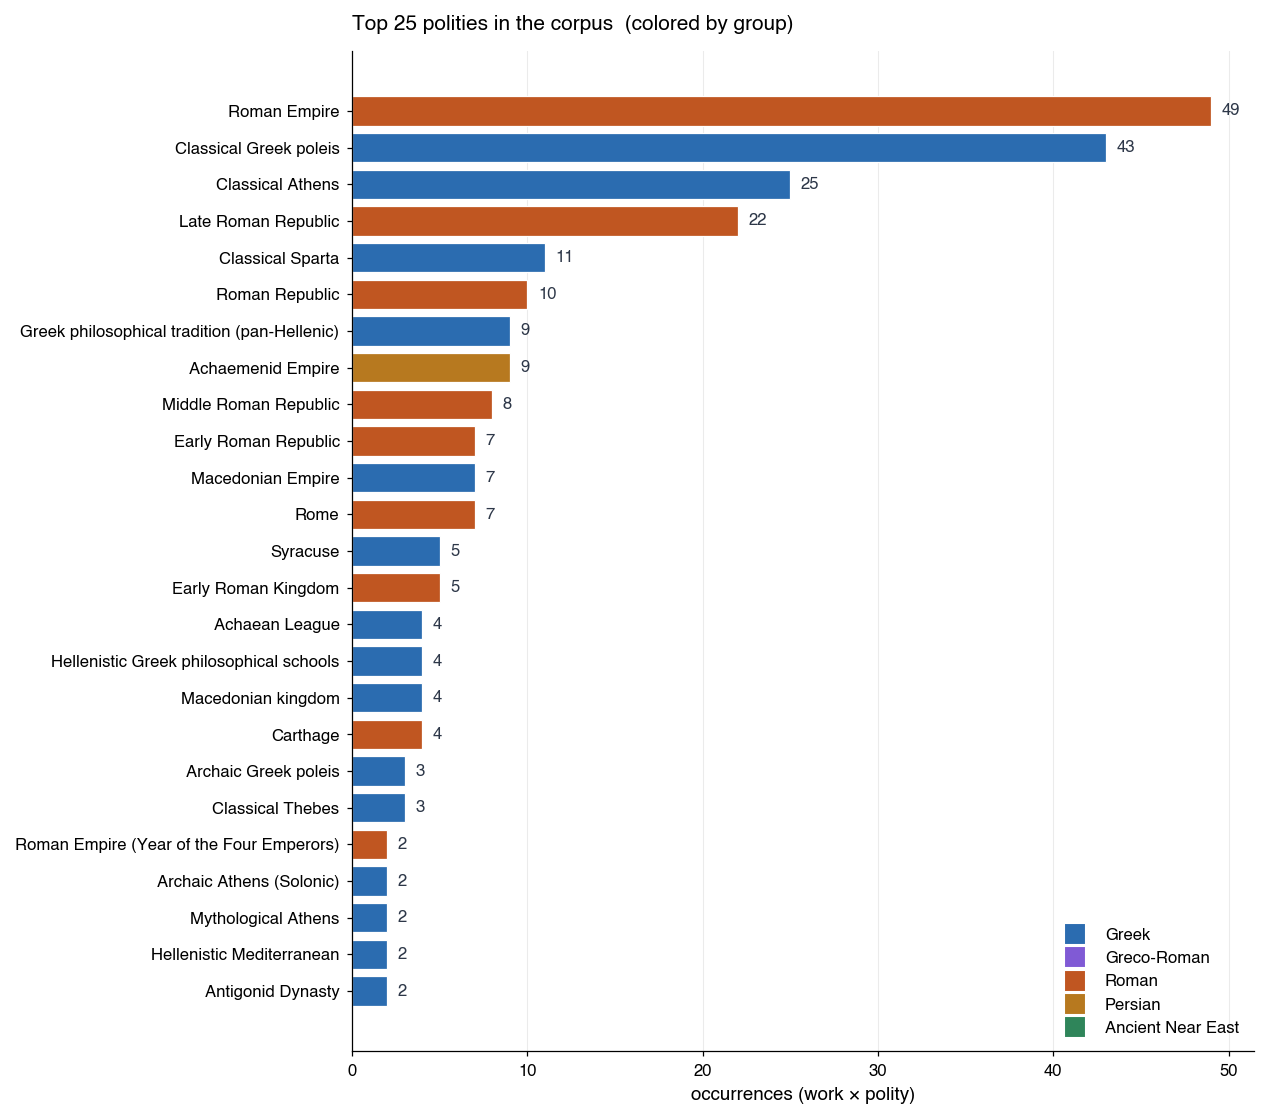

In [6]:
TOP_N = 25
top = raw_counts.head(TOP_N)[::-1]           # reverse so largest is on top
colors = [GROUP_COLORS[POLITY_TO_GROUP[p]] for p in top.index]

fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.barh(top.index, top.values, color=colors,
        edgecolor='white', linewidth=0.6)

for y, v in enumerate(top.values):
    ax.text(v + 0.6, y, str(int(v)), va='center', fontsize=8, color='#2d3748')

ax.set_xlabel('occurrences (work × polity)')
ax.set_title(f'Top {TOP_N} polities in the corpus  (colored by group)',
             loc='left', pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.25, linewidth=0.5)
ax.set_axisbelow(True)

handles = [Line2D([0], [0], marker='s', linestyle='',
                  markerfacecolor=GROUP_COLORS[g], markeredgecolor='white',
                  markersize=11, label=g)
           for g in GROUP_ORDER]
ax.legend(handles=handles, loc='lower right', frameon=False, fontsize=8)
fig.tight_layout()

## 5. Preprocessing

Merge mapping ↔ meta ↔ author dates. Keep historians **plus** the two
pseudepigraphic author codes. Explode multi-polity works into one row
per `(work × polity)` and apply `POLITY_TO_GROUP`.

For each `(work × polity)` row we also compute a **segment**
`[seg_start, seg_end]` by splitting the work's time span
(`subject_year` → `subject_end`) into equal consecutive sub-intervals
— one per polity, preserving the order in which they appear in the
source label. A work with 4 polities thus contributes 4 colored
segments laid end-to-end across its time span.

In [7]:
meta_cols = ['file_id', 'perseus_id', 'perseus_author', 'perseus_title',
             'historian', 'author_code', 'author_impact_date', 'n_pages']
df = pt.merge(meta[meta_cols], on='file_id', how='left')

n0 = len(df)
df = df[(df['historian'] == 1) | (df['author_code'].isin(PSEUDO_AUTHOR_CODES))].copy()
n1 = len(df)

# Canonicalise author labels for the two pseudepigraphic codes (one
# Perseus TEI file mislabels tlg0061 as "Lucian of Samosata").
for code, label in PSEUDO_AUTHOR_CODES.items():
    df.loc[df['author_code'] == code, 'perseus_author'] = label

df = df.merge(authors, on='perseus_author', how='left')

# Parse time / author year columns up-front so segment math is clean.
df['subject_year']  = pd.to_numeric(df['mentioned_time_start_in_work'], errors='coerce')
df['subject_end']   = pd.to_numeric(df['mentioned_time_end_in_work'],   errors='coerce')
df['author_year']   = pd.to_numeric(df['author_impact_date'], errors='coerce')
df['deathdate']     = pd.to_numeric(df['deathdate'], errors='coerce')
df['birthdate']     = pd.to_numeric(df['birthdate'], errors='coerce')
df['n_pages']       = pd.to_numeric(df['n_pages'], errors='coerce').fillna(1)
# Diamond marker = deathdate (work finalised by then), fallback to floruit.
df['author_marker'] = df['deathdate'].fillna(df['author_year'])

# Explode multi-polity works → one row per (file_id, polity), preserving order.
df['polity_list'] = (df['mentioned_polities_in_work'].fillna('')
                       .astype(str).str.split(r';\s*'))
df = df.explode('polity_list').rename(
    columns={'polity_list': 'mentioned_polity_in_work'})
df['mentioned_polity_in_work'] = df['mentioned_polity_in_work'].str.strip()
df = df[df['mentioned_polity_in_work'] != ''].copy()
n2 = len(df)

# Apply explicit polity → group mapping.
df['polity_group'] = df['mentioned_polity_in_work'].map(POLITY_TO_GROUP)
assert df['polity_group'].notna().all(), \
    f"Unmapped polities: {df.loc[df['polity_group'].isna(), 'mentioned_polity_in_work'].unique()}"

# Sequential segments within each work: split [subject_year, subject_end]
# into equal consecutive sub-intervals, one per polity.
df['polity_idx']   = df.groupby('file_id').cumcount()
df['polity_count'] = df.groupby('file_id')['file_id'].transform('count')
df['seg_width']    = (df['subject_end'] - df['subject_year']) / df['polity_count']
df['seg_start']    = df['subject_year'] + df['polity_idx'] * df['seg_width']
df['seg_end']      = df['seg_start'] + df['seg_width']

df = df[df['subject_year'].notna() & df['author_year'].notna()].copy()
n3 = len(df)

print(f'After merge:                      {n0:,}')
print(f'After historian + pseudo filter:  {n1:,}  (dropped {n0-n1})')
print(f'After exploding polities:         {n2:,}  (expanded from {n1})')
print(f'After require subject+author yr:  {n3:,}  (dropped {n2-n3})')
print(f'\n{df["file_id"].nunique()} works | '
      f'{df["perseus_author"].nunique()} authors | '
      f'{df["mentioned_polity_in_work"].nunique()} distinct polities | '
      f'{df["polity_group"].nunique()} groups')
df[['perseus_author', 'perseus_title', 'mentioned_polity_in_work',
    'polity_group', 'subject_year', 'subject_end',
    'seg_start', 'seg_end']].head()

After merge:                      181
After historian + pseudo filter:  181  (dropped 0)
After exploding polities:         306  (expanded from 181)
After require subject+author yr:  306  (dropped 0)

181 works | 11 authors | 72 distinct polities | 5 groups


,perseus_author,perseus_title,mentioned_polity_in_work,polity_group,subject_year,subject_end,seg_start,seg_end
0,Thucydides,The Peloponnesian War,Classical Athens,Greek,-431,-411,-431.0,-421.0
0,Thucydides,The Peloponnesian War,Classical Sparta and Peloponnesian League,Greek,-431,-411,-421.0,-411.0
1,Diogenes Laertius,Lives of Eminent Philosophers,Greek philosophical tradition (pan-Hellenic),Greek,-600,300,-600.0,300.0
2,Plutarch,Demosthenes,Classical Athens,Greek,-384,-322,-384.0,-322.0
3,Plutarch,Galba,Roman Empire (Year of the Four Emperors),Roman,68,69,68.0,69.0


## 6. Group-level counts (historian subset)

Sanity check: how many `(work × polity)` rows fall in each group
after applying the mapping to the historian subset.

In [8]:
df['polity_group'].value_counts().reindex(GROUP_ORDER).fillna(0).astype(int)

polity_group
Greek                152
Greco-Roman            4
Roman                129
Persian               13
Ancient Near East      8
Name: count, dtype: int64

## 7. Summary — one row per historian

In [9]:
summary = (df.groupby('perseus_author')
             .agg(n_works=('file_id', 'nunique'),
                  author_year=('author_year', 'first'),
                  subject_min=('subject_year', 'min'),
                  subject_max=('subject_year', 'max'),
                  n_polities=('mentioned_polity_in_work', 'nunique'))
             .sort_values('author_year'))
summary['span_years'] = (summary['subject_max']
                         - summary['subject_min']).astype(int)
summary

,n_works,author_year,subject_min,subject_max,n_polities,span_years
perseus_author,,,,,,
Herodotus,1,-448,-560,-560,4,0
Thucydides,1,-425,-431,-431,2,0
Xenophon,9,-394,-559,-365,8,194
Polybius,1,-164,-264,-264,5,0
Strabo,1,-27,-200,-200,5,0
Flavius Josephus,4,72,-2000,66,5,2066
Plutarch,141,75,-2500,100,43,2600
Appian of Alexandria,15,130,-753,-89,18,664
Pseudo-Lucian,4,150,-1200,150,5,1350


## 8. Figures

### Figure 1: Temporal & political coverage per historian

Each work is a horizontal bar from `subject_year` → `subject_end`.
Works that cover multiple polities are split into equal consecutive
sub-segments, each colored by its polity group. The white diamond
marks the author's end-of-life (fallback: floruit), and the date in
parentheses after the author name is the `author_impact_date`
(floruit).

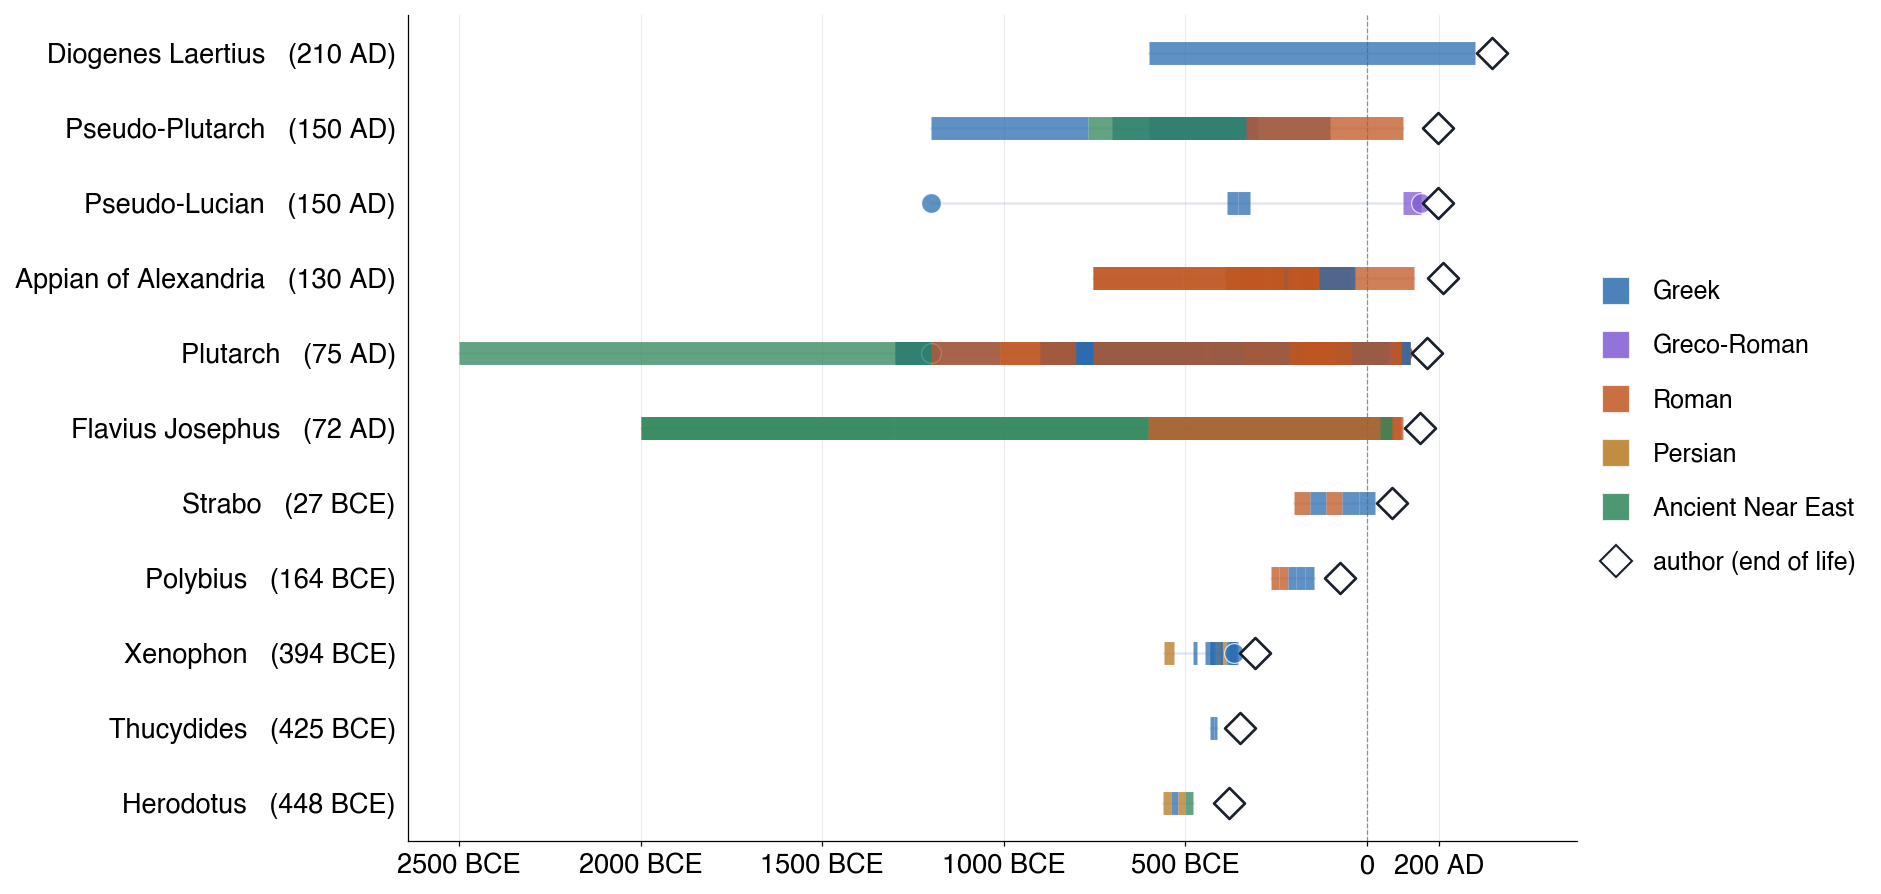

In [10]:
def era_label(year):
    y = int(year)
    return f'{abs(y)} BCE' if y < 0 else f'{y} AD'


historians = summary.index.tolist()
y_pos = {h: i for i, h in enumerate(historians)}

SEG_LW = 11
# Diamond offset past the rightmost segment — fraction of the x-range.
MARKER_OFFSET_FRAC = 0.015

fig, ax = plt.subplots(figsize=(13.5, 6.0))

# Per-author rightmost segment end, used to pin the diamond past it.
last_seg_end = df.groupby('perseus_author')['seg_end'].max()

for h in historians:
    i = y_pos[h]
    sub = df[df['perseus_author'] == h]

    ax.plot([sub['subject_year'].min(), sub['subject_end'].max()], [i, i],
            color='#e2e8f0', linewidth=1.2, zorder=1)

    for _, r in sub.iterrows():
        color = GROUP_COLORS[r['polity_group']]
        if r['seg_end'] == r['seg_start']:
            ax.scatter([r['seg_start']], [i],
                       s=90, c=[color], alpha=0.75,
                       edgecolor='white', linewidth=0.6, zorder=3)
        else:
            ax.plot([r['seg_start'], r['seg_end']], [i, i],
                    color=color, linewidth=SEG_LW, alpha=0.75,
                    solid_capstyle='butt', zorder=3)

# Compute x-range once (after segments are drawn) so the offset is
# consistent across rows.
x0, x1 = ax.get_xlim()
offset = (x1 - x0) * MARKER_OFFSET_FRAC

# Diamond = max(author_marker, rightmost segment end) + offset, so it
# always sits strictly after the colored points on that row.
for h in historians:
    i = y_pos[h]
    author_marker = df.loc[df['perseus_author'] == h, 'author_marker'].iloc[0]
    pos = max(author_marker, last_seg_end[h]) + offset
    ax.scatter([pos], [i],
               marker='D', s=110, facecolor='white',
               edgecolor='#1a202c', linewidth=1.3, zorder=10)

# Expand xlim slightly so the rightmost diamond isn't clipped.
ax.set_xlim(x0, x1 + offset * 3)

ax.set_yticks(range(len(historians)))
ax.set_yticklabels(
    [f'{h}   ({era_label(summary.loc[h, "author_year"])})' for h in historians],
    fontsize=13, fontweight='bold')

xticks = [-2500, -2000, -1500, -1000, -500, 0, 200]
ax.set_xticks(xticks)
ax.set_xticklabels([era_label(t) if t != 0 else '0' for t in xticks], fontsize=13)
ax.set_xlabel('')

ax.axvline(0, color='#4a5568', linewidth=0.6, linestyle='--', alpha=0.6)
ax.grid(axis='x', alpha=0.25, linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', length=0, pad=6)

handles = [Line2D([0], [0], marker='s', linestyle='',
                  markerfacecolor=GROUP_COLORS[g], markeredgecolor='white',
                  markersize=13, label=g, alpha=0.85)
           for g in GROUP_ORDER]
handles.append(Line2D([0], [0], marker='D', linestyle='',
                      markerfacecolor='white', markeredgecolor='#1a202c',
                      markersize=11, label='author (end of life)'))
ax.legend(handles=handles,
          loc='center left', bbox_to_anchor=(1.01, 0.5),
          frameon=False, fontsize=12,
          handlelength=1.4, labelspacing=1.2, borderaxespad=0)

fig.tight_layout()
plt.subplots_adjust(right=0.78)

## 9. Tables

### 9.1 Top-3 polities per historian

In [11]:
top_raw = (df.groupby(['perseus_author', 'mentioned_polity_in_work'])
                .size().reset_index(name='n')
                .sort_values(['perseus_author', 'n'],
                             ascending=[True, False])
                .groupby('perseus_author')
                .head(3))
top_raw

,perseus_author,mentioned_polity_in_work,n
14,Appian of Alexandria,Rome,6
0,Appian of Alexandria,Carthage,3
13,Appian of Alexandria,Roman Republic,3
18,Diogenes Laertius,Greek philosophical tradition (pan-Hellenic),1
19,Flavius Josephus,Ancient Israel / Second Temple Judaism,2
20,Flavius Josephus,Judea,2
23,Flavius Josephus,Roman Empire (Flavian),2
24,Herodotus,Achaemenid Empire,1
25,Herodotus,Classical Greek poleis,1
26,Herodotus,Lydia,1


### 9.2 Authors who never address Greek culture

Authors in the historian subset whose works contain **no**
`polity_group ∈ {'Greek', 'Greco-Roman'}` rows — i.e. they only
engage with Roman, Persian, or Ancient Near Eastern polities.

In [12]:
GREEK_GROUPS = {'Greek', 'Greco-Roman'}

author_groups = (df.groupby('perseus_author')['polity_group']
                   .agg(lambda s: set(s)))
no_greek = author_groups[~author_groups.apply(lambda gs: bool(gs & GREEK_GROUPS))]

if no_greek.empty:
    print('Every author in the corpus addresses Greek culture at least once.')
else:
    print(f'{len(no_greek)} author(s) never address Greek culture:\n')
    out = (summary.loc[no_greek.index, ['n_works', 'author_year', 'n_polities']]
           .assign(groups_covered=no_greek.apply(lambda gs: ', '.join(sorted(gs)))))
    print(out.to_string())
    out

1 author(s) never address Greek culture:

                  n_works  author_year  n_polities            groups_covered
perseus_author                                                              
Flavius Josephus        4           72           5  Ancient Near East, Roman
